In [28]:
import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_palette("husl")

In [29]:
glass_identification = fetch_ucirepo(id=42)

X = glass_identification.data.features
y = glass_identification.data.targets

In [11]:
records, n_features = X.shape
f"GLASS: number of records: {records}, number of features: {n_features}"

'GLASS: number of records: 214, number of features: 9'

In [12]:
nulls = pd.DataFrame(X).isnull().sum()
nulls

RI    0
Na    0
Mg    0
Al    0
Si    0
K     0
Ca    0
Ba    0
Fe    0
dtype: int64

In [13]:
X

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0
...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0


___

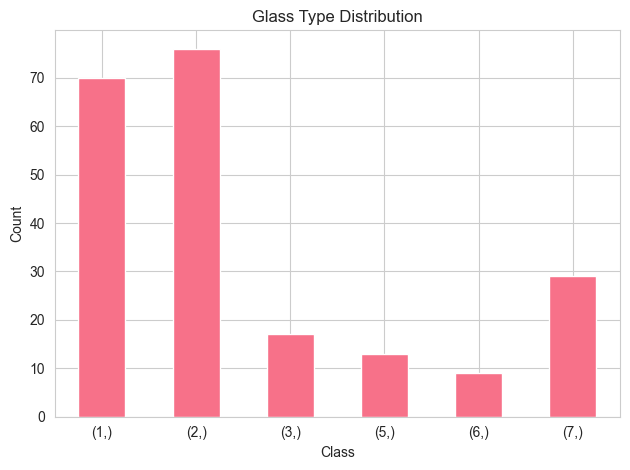

In [14]:
ax = y.value_counts().sort_index().plot(kind="bar")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.set_title("Glass Type Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Feature distributions by class

In [15]:
df = X.copy()
df['species'] = y.values.ravel().astype(str)
features = X.columns

classes = sorted(df['species'].unique())
colors = sns.color_palette('husl', len(classes))
palette = {cls: color for cls, color in zip(classes, colors)}

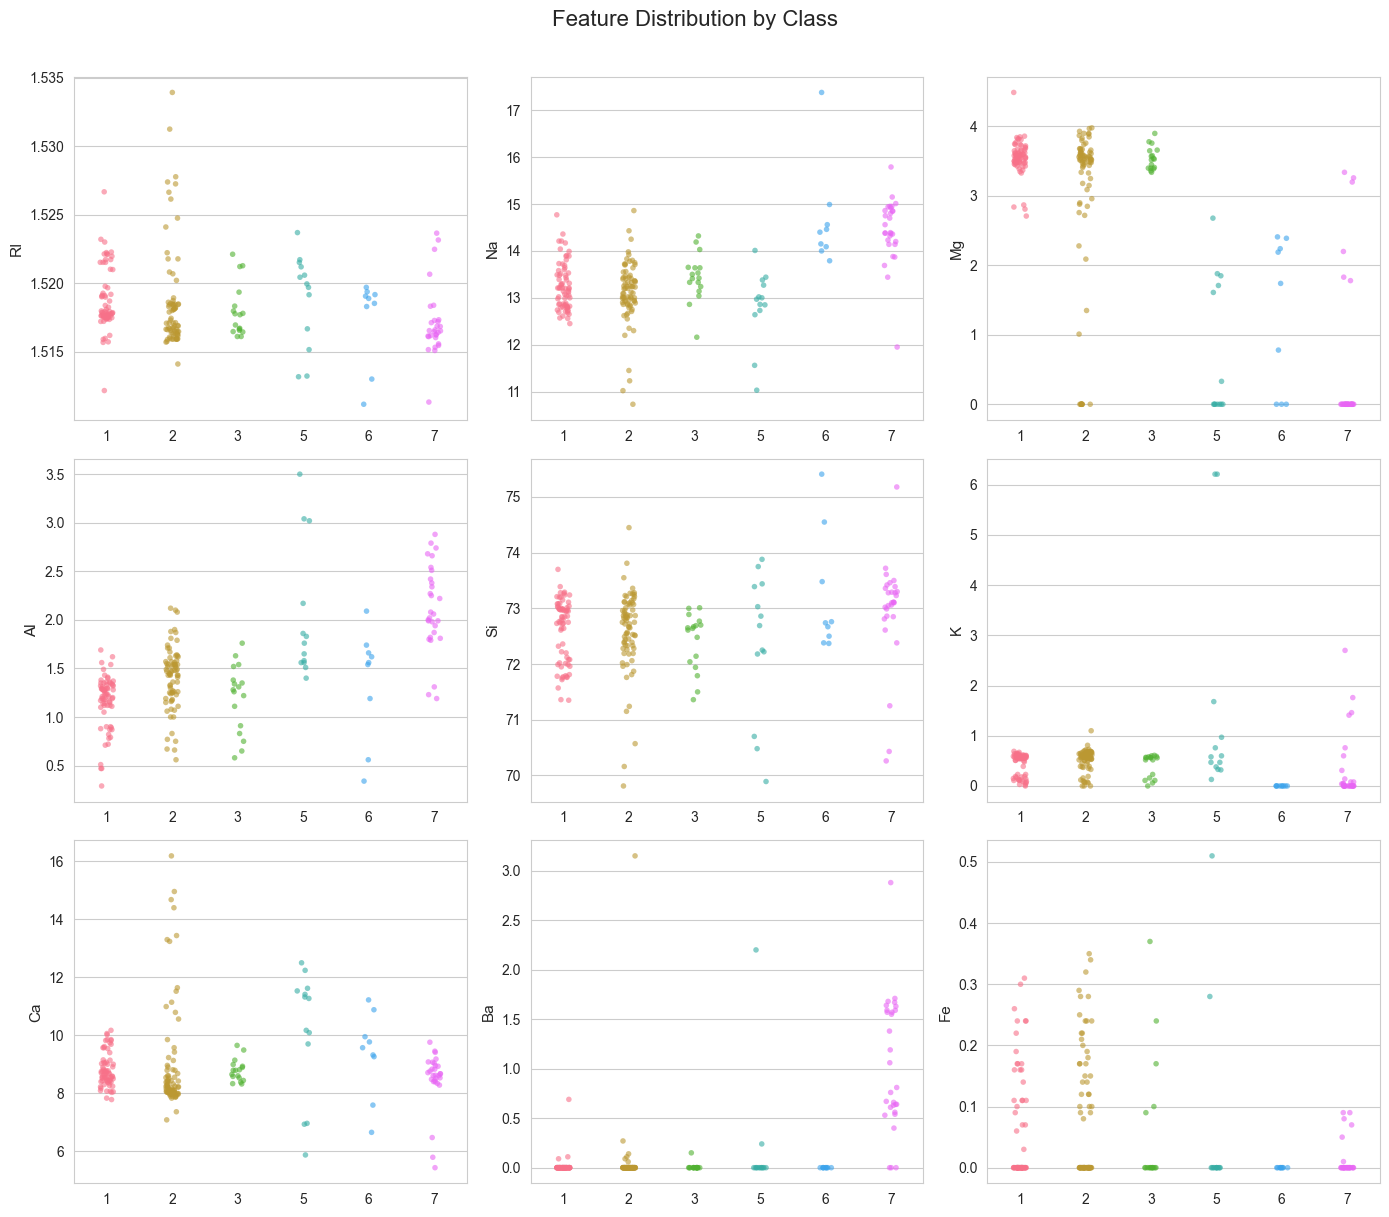

In [16]:
n_cols = 3
n_rows = int(np.ceil(len(features) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 4))
fig.suptitle("Feature Distribution by Class", fontsize=16, y=1.01)
axes = axes.flatten()

for idx, feature in enumerate(features):
    sns.stripplot(
        data=df,
        x="species",
        y=feature,
        hue="species",
        ax=axes[idx],
        palette=palette,
        alpha=0.6,
        size=4,
        legend=False,
    )
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel(feature, fontsize=11)
    axes[idx].tick_params(axis="x", rotation=0)

for ax in axes[len(features) :]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
X.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000


In [18]:
features = X.columns
features

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe'], dtype='str')

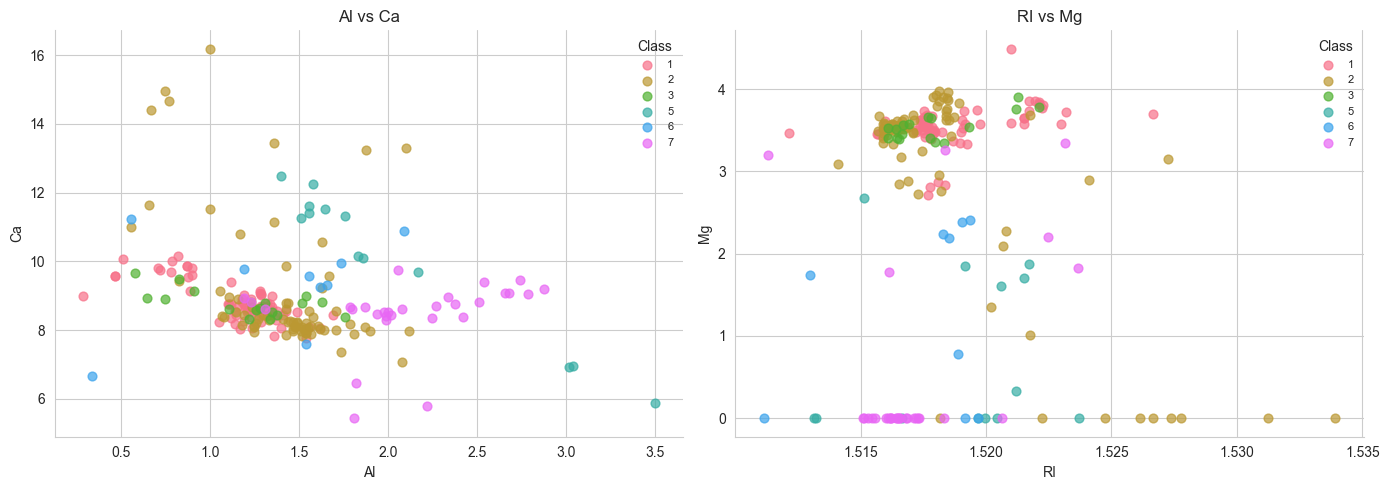

In [19]:
# Dwie wybrane pary cech
pairs = [(features[3], features[6]), (features[0], features[2])]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (fx, fy) in zip(axes, pairs):
    for cls, group in df.groupby("species"):
        ax.scatter(group[fx], group[fy], label=cls, alpha=0.7, s=40, color=palette[cls])
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.set_title(f"{fx} vs {fy}")
    ax.legend(title="Class", frameon=False, fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

### PCA

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

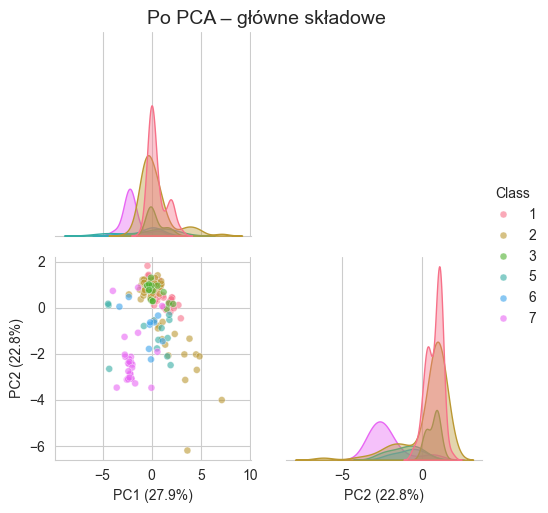

In [26]:
var = pca.explained_variance_ratio_ * 100
df_pca = pd.DataFrame(X_pca, columns=[f"PC1 ({var[0]:.1f}%)", f"PC2 ({var[1]:.1f}%)"])
df_pca["species"] = df["species"].values

g = sns.PairGrid(df_pca, hue="species", palette=palette, corner=True)
g.map_lower(sns.scatterplot, alpha=0.6, s=25)
g.map_diag(sns.kdeplot, fill=True, alpha=0.4, warn_singular=False)
g.add_legend(title="Class", frameon=False)

g.figure.suptitle("Po PCA – główne składowe", y=1.01, fontsize=14)
plt.show()

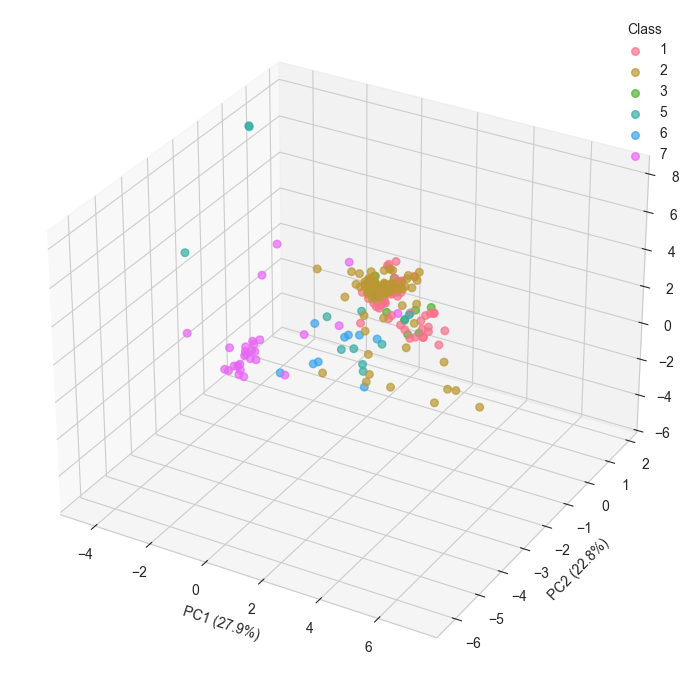

In [27]:
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

var3 = pca3.explained_variance_ratio_ * 100
df_pca3 = pd.DataFrame(
    X_pca3,
    columns=[f"PC1 ({var3[0]:.1f}%)", f"PC2 ({var3[1]:.1f}%)", f"PC3 ({var3[2]:.1f}%)"],
)
df_pca3["species"] = df["species"].values

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

for cls in classes:
    mask = df_pca3["species"] == cls
    ax.scatter(
        df_pca3.loc[mask, df_pca3.columns[0]],
        df_pca3.loc[mask, df_pca3.columns[1]],
        df_pca3.loc[mask, df_pca3.columns[2]],
        label=str(cls),
        color=palette[cls],
        alpha=0.7,
        s=30,
    )

ax.set_xlabel(df_pca3.columns[0])
ax.set_ylabel(df_pca3.columns[1])
ax.set_zlabel(df_pca3.columns[2])
ax.legend(title="Class", frameon=False)
plt.tight_layout()
plt.show()